In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
from cartopy.util import add_cyclic_point
import matplotlib.colors as mcolors

/pscratch/sd/j/jungchoi/DCPP/_metrics/CanESM5/siconc.YR1.mon_trend1979-2014.em.nc
<xarray.Dataset> Size: 12MB
Dimensions:    (i: 360, j: 291, month: 12)
Coordinates:
    degree     int64 8B ...
  * i          (i) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
  * j          (j) int32 1kB 0 1 2 3 4 5 6 7 ... 283 284 285 286 287 288 289 290
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    latitude   (j, i) float64 838kB ...
    longitude  (j, i) float64 838kB ...
Data variables:
    siconc     (month, j, i) float64 10MB ...
mdl_bimon== <xarray.Dataset> Size: 7MB
Dimensions:    (i: 360, j: 291, month: 6)
Coordinates:
    degree     int64 8B ...
  * i          (i) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
  * j          (j) int32 1kB 0 1 2 3 4 5 6 7 ... 283 284 285 286 287 288 289 290
    latitude   (j, i) float64 838kB ...
    longitude  (j, i) float64 838kB ...
  * month      (month) int64 48B 1 2 3 4 5 6
Data variables:
    siconc     (m

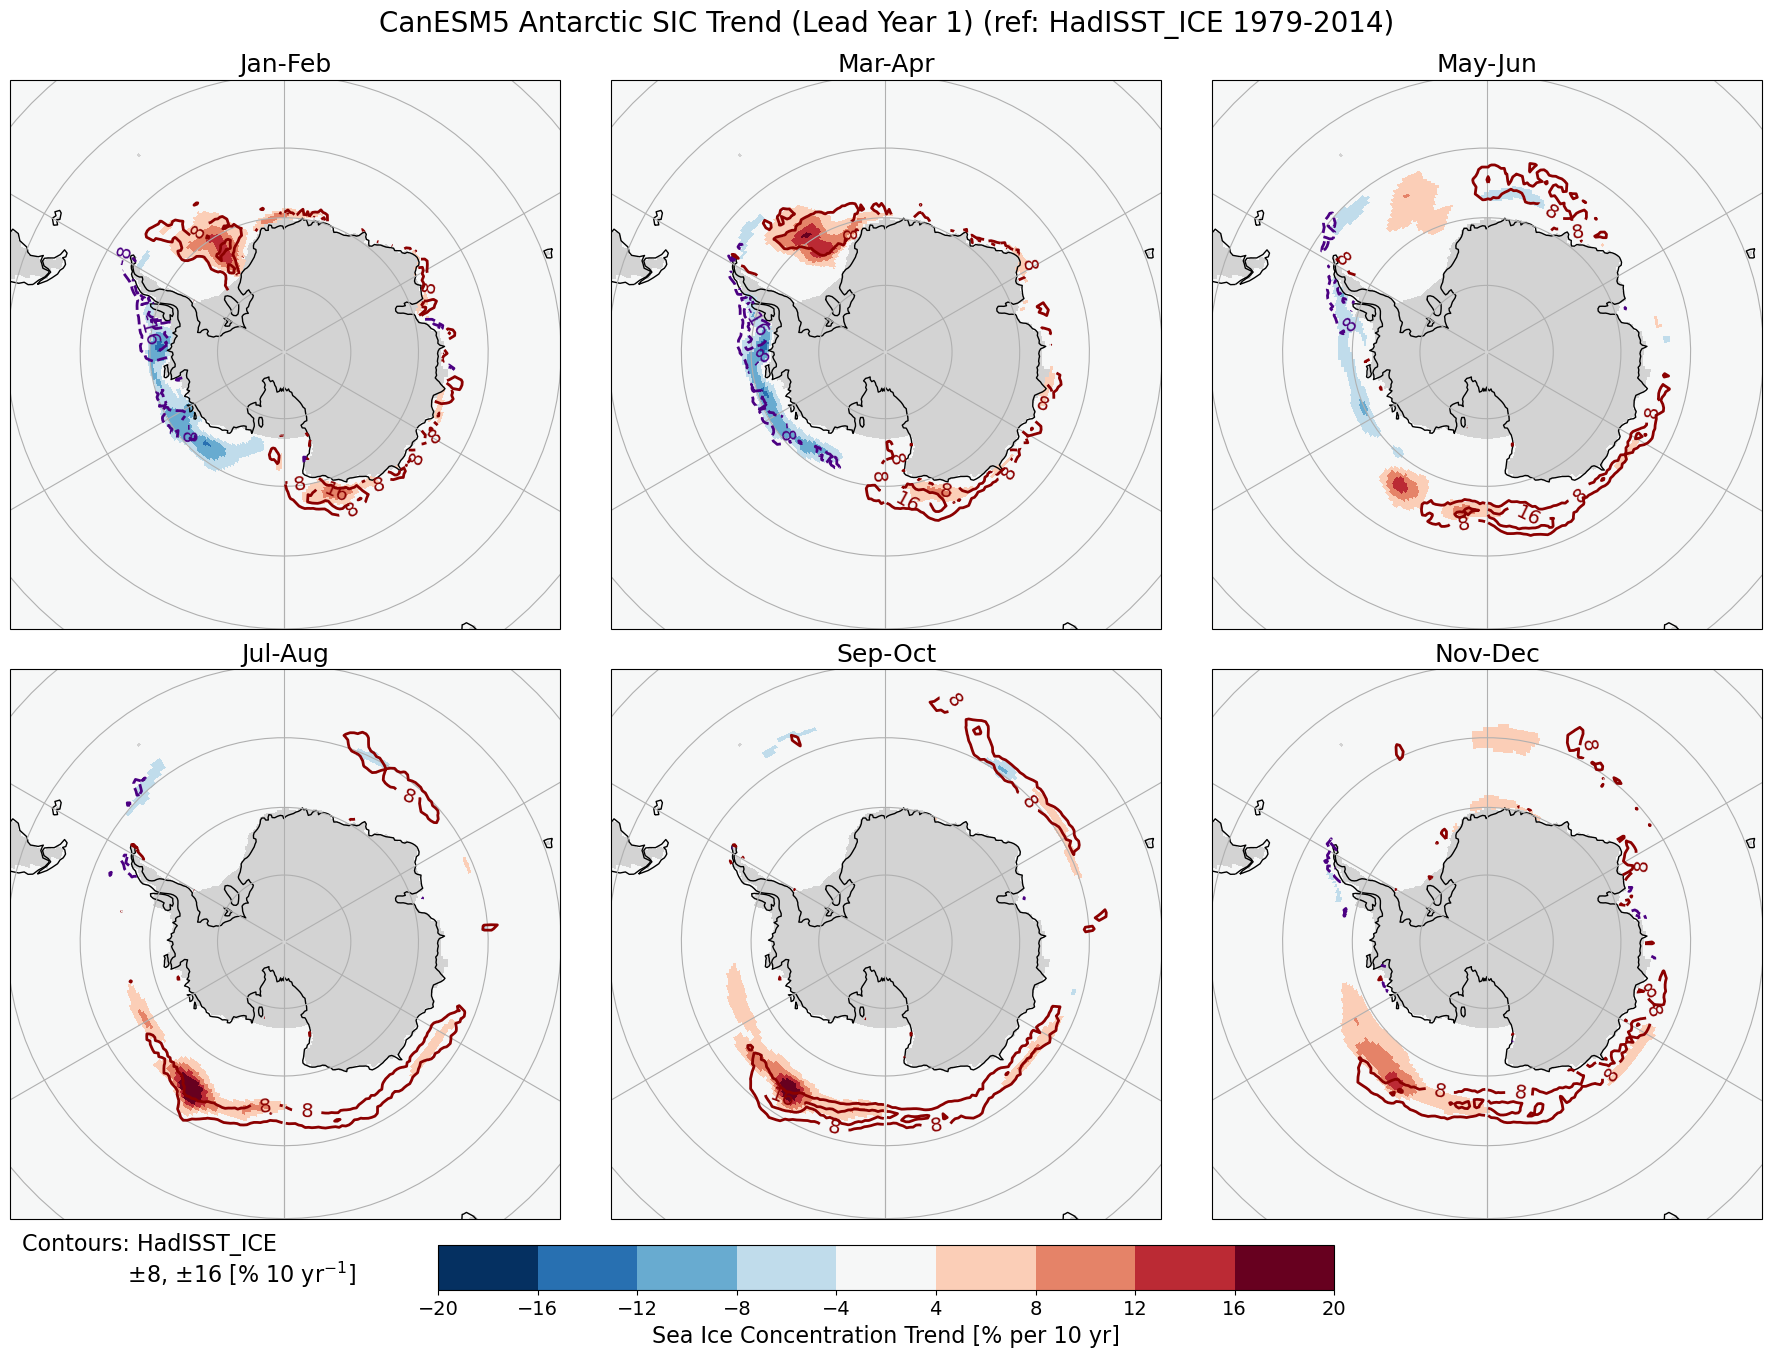

***DONE***


In [2]:
ds_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"

case = "mon_trend1979-2014.em"
var_name = "siconc"
figout_dir = "/global/cfs/projectdirs/m4581/jungchoi/PMP/GMD2026/Fig6/_subplots"

#model_list = ['CanESM5', 'CMCC-CM2-SR5', 'CNRM-ESM2-1', 
#              'EC-Earth3', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 
#              'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1']
#model_list = ['CMCC-CM2-SR5']
#model_list = ['EC-Earth3']
model_list = ['CanESM5']

#lead_yr_list = ['HIST', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
lead_yr_list = ['1']


#region = "arctic"
region = "antarctic"

#Read observed climatology
obs_file = f"{ds_dir}/OBS/{var_name}.360x180.mon_trend1979-2014.nc"   
obs_ds = xr.open_dataset(obs_file)
obs_ds = obs_ds * 10.   #unit: [%/decade]
#print(obs_ds)
obs_ds.close()

for model in model_list:
    end_lead = len(lead_yr_list) + 1
    if model in ['CNRM-ESM2-1', 'MRI-ESM2-0']:
        end_lead = 5 + 1
        
    for lead_yr in lead_yr_list[0:end_lead]:
        if lead_yr == 'HIST':
            mdl_file = f"{ds_dir}/{model}/{var_name}.historical.{case}.nc"
            lead_title = "Historical"
            lead_out = "HIST"
        else:
            mdl_file = f"{ds_dir}/{model}/{var_name}.YR{lead_yr}.{case}.nc"    
            lead_title = f"Lead Year {lead_yr}"
            lead_out = f"LY{lead_yr}"
        
        mdl_ds = xr.open_dataset(mdl_file)
        print(mdl_file)
        print(mdl_ds)
        mdl_ds.close()
        
        mdl_ds = mdl_ds * 10.   #unit: [%/decade]

        # Define bias and 2-month average
        obs_bimonthly_group = ((obs_ds['month'] - 1) // 2) + 1
        obs_bimonthly_means = obs_ds.groupby(obs_bimonthly_group).mean(dim='month')
        mdl_bimonthly_group = ((mdl_ds['month'] - 1) // 2) + 1
        siconc = mdl_ds['siconc']
        lon = mdl_ds['longitude']
        lat = mdl_ds['latitude']
        mdl_bimonthly_means = siconc.groupby(mdl_bimonthly_group).mean(dim='month')
        mdl_bimonthly_means = mdl_bimonthly_means.to_dataset(name='siconc')
        mdl_bimonthly_means = mdl_bimonthly_means.assign_coords(longitude=lon)
        mdl_bimonthly_means = mdl_bimonthly_means.assign_coords(latitude=lat)
        print('mdl_bimon==', mdl_bimonthly_means)
        
        lons = obs_ds.longitude
        lats = obs_ds.latitude
        lon2d, lat2d = np.meshgrid(lons, lats)
        
        labels = ['Jan-Feb', 'Mar-Apr', 'May-Jun', 'Jul-Aug', 'Sep-Oct', 'Nov-Dec']
        
        if region == "arctic":
            title = "Arctic"
            fig, axs = plt.subplots(2, 3, figsize=(18, 13),
                                subplot_kw={'projection': ccrs.NorthPolarStereo()},
                                constrained_layout=True)
        if region == "antarctic":
            title = "Antarctic"
            fig, axs = plt.subplots(2, 3, figsize=(18, 13),
                                subplot_kw={'projection': ccrs.SouthPolarStereo()},
                                constrained_layout=True)

        # shading level
        #bounds = np.arange(-15, 18, 3)  # -15, -12, -9, ..., 15
        #bounds = np.array([-18, -15, -12, -9, -6, -3, 3, 6, 9, 12, 15, 18])
        bounds = np.array([-20, -16, -12, -8, -4, 4, 8, 12, 16, 20])
        colors = [
            plt.cm.RdBu_r(0.0),  # 진한 푸른색 (-15 근처)
            plt.cm.RdBu_r(0.2),
            'white',              # -3~3 사이 흰색
            plt.cm.RdBu_r(0.8),
            plt.cm.RdBu_r(1.0)   # 진한 붉은색 (+15 근처)
        ]
        custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_RdBu_white", colors, N=256)
        norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)
        
        for i in range(6):
            row = i // 3
            col = i % 3
            ax = axs[row, col]
        
            mdl_i = mdl_bimonthly_means.sel(month=i+1)
            obs_i = obs_bimonthly_means.sel(month=i+1)
            
            if region == "arctic":
                print('arctic is working')
                mdl_polar = mdl_i.where(mdl_i['latitude'] >= 30)
                obs_polar = obs_i.where(obs_i['latitude'] >= 30)
                lat1 = 45
                lat2 = 90
        
            if region == "antarctic":
                print('antactic is working')
                mdl_polar = mdl_i.where(mdl_i['latitude'] <= -30)
                ##mdl_polar = mdl_i
                obs_polar = obs_i.where(obs_i['latitude'] <= -30)
                print('antactic is working DONE')
                lat1 = -90
                lat2 = -50
        
            #print('%%%%%%%%%% mdl==', mdl_polar)
            #print('%%%%%%%%%% obs==', obs_polar)
            mdl_data = mdl_polar['siconc']
            mdl_lon = mdl_polar['longitude']
            mdl_lat = mdl_polar['latitude']
            obs_data = obs_polar['siconc']
            #print('%%%%%%%%%% mdl_data, lon, lat==', mdl_data, mdl_lon, mdl_lat)
            #print('%%%%%%%%%% obs_data==', obs_data)
            
            #mdl_data = mdl_data.assign_coords(
            #    longitude=(((mdl_data.longitude + 180) % 360) - 180))
          
            ax.set_extent([-180, 180, lat1, lat2], crs=ccrs.PlateCarree())
            ax.coastlines()
            ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
            ax.gridlines(draw_labels=False)
        
            im = ax.pcolormesh(
                mdl_lon, mdl_lat, mdl_data,
                transform=ccrs.PlateCarree(),
                #cmap=custom_cmap, norm=norm,
                cmap='RdBu_r',
                norm=norm,
                shading='auto'
            )
        
            neg_levels = [-16, -8]
            pos_levels = [8, 16]
            
            # 음수 contour → 푸른색 계열
            cs_neg = ax.contour(
                obs_data['longitude'], obs_data['latitude'], obs_data,
                levels=neg_levels,
                #colors='#003366',      # 짙은 네이비
                colors='indigo',
                linewidths=2,
                transform=ccrs.PlateCarree()
            )
            
            # 양수 contour → 붉은색 계열
            cs_pos = ax.contour(
                obs_data['longitude'], obs_data['latitude'], obs_data,
                levels=pos_levels,
                colors='#8B0000',      # 진한 다크레드
                linewidths=2,
                transform=ccrs.PlateCarree()
            )
            
            # ===== 4️⃣ 라벨 추가 =====
            ax.clabel(cs_neg, fmt='%d', inline=True, fontsize=14, colors='indigo')
            ax.clabel(cs_pos, fmt='%d', inline=True, fontsize=14, colors='#8B0000')
            
            ax.set_facecolor('lightgray')
            ax.set_title(labels[i], fontsize=18)
        
        fig.suptitle(f"{model} {title} SIC Trend ({lead_title}) (ref: HadISST_ICE 1979-2014)", fontsize=20, y=1.03)
        cbar = fig.colorbar(im, ax=axs.ravel().tolist(), orientation='horizontal', pad=0.02, shrink=0.5)
        #cbar.set_label('Sea Ice Concentration Trned [%$\cdot$decade$^{-1}$]', fontsize=16)
        cbar.set_label('Sea Ice Concentration Trend [% per 10 yr]', fontsize=16)
        cbar.ax.tick_params(labelsize=14) 
        
        #fig.text(0.02, 0.06, 'Red line: Model 15%', fontsize=16, ha='left', va='bottom', color='black')
        fig.text(0.02, 0.045, 'Contours: HadISST_ICE \n               ±8, ±16 [% 10 yr$^{-1}$]', fontsize=16, ha='left', va='bottom', color='black')

        #plt.savefig(f"{figout_dir}/Trend_SIC.{title}.{model}.{lead_out}.png", dpi=300, bbox_inches='tight', transparent=False)
        #plt.savefig(f"_figs/_Fig6/Trend_SIC.{title}.{model}.{lead_out}.png", dpi=300, bbox_inches='tight', transparent=False)
        plt.savefig(f"_figs/Fig8.eps", dpi=300, bbox_inches='tight', transparent=False)
        plt.show()


print('***DONE***')

In [ ]:
print(mdl_data.min().values, mdl_data.max().values)